In [ ]:
from neo4j import GraphDatabase
import networkx as nx
import pandas as pd

In [2]:
primekg = pd.read_csv("./PrimeKG.csv", index_col=0)
#prime_nodes = pd.read_csv("./nodes.csv", index_col=0)
primekg

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_11716/2774168028.py:1: DtypeWarning: Columns (0: x_type, 1: y_type) have mixed types. Specify dtype option on import or set low_memory=False.
  primekg = pd.read_csv("./PrimeKG.csv", index_col=0)


,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source
relation,,,,,,,,,,,
protein_protein,ppi,0,9796,gene/protein,PHYHIP,NCBI,8889,56992,gene/protein,KIF15,NCBI
protein_protein,ppi,1,7918,gene/protein,GPANK1,NCBI,2798,9240,gene/protein,PNMA1,NCBI
protein_protein,ppi,2,8233,gene/protein,ZRSR2,NCBI,5646,23548,gene/protein,TTC33,NCBI
protein_protein,ppi,3,4899,gene/protein,NRF1,NCBI,11592,11253,gene/protein,MAN1B1,NCBI
protein_protein,ppi,4,5297,gene/protein,PI4KA,NCBI,2122,8601,gene/protein,RGS20,NCBI
...,...,...,...,...,...,...,...,...,...,...,...
anatomy_protein_absent,expression absent,66747,4720,anatomy,cerebellar vermis,UBERON,5259,140,gene/protein,ADORA3,NCBI
anatomy_protein_absent,expression absent,63824,1377,anatomy,quadriceps femoris,UBERON,58254,105378952,gene/protein,KLF18,NCBI
anatomy_protein_absent,expression absent,63826,1379,anatomy,vastus lateralis,UBERON,58254,105378952,gene/protein,KLF18,NCBI


In [3]:
primekg[primekg['x_name']=="Alzheimer disease"]

,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source
relation,,,,,,,,,,,
disease_phenotype_positive,phenotype present,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,22999,2015,effect/phenotype,Dysphagia,HPO
disease_phenotype_positive,phenotype present,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,91412,31868,effect/phenotype,Optic ataxia,HPO
disease_phenotype_positive,phenotype present,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,22998,1288,effect/phenotype,Gait disturbance,HPO
disease_phenotype_positive,phenotype present,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,24284,2354,effect/phenotype,Memory impairment,HPO
disease_phenotype_positive,phenotype present,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,85516,3487,effect/phenotype,Babinski sign,HPO
...,...,...,...,...,...,...,...,...,...,...,...
exposure_disease,linked to,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,61777,D009589,exposure,Nitrogen Oxides,CTD
exposure_disease,linked to,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,61782,D010126,exposure,Ozone,CTD
exposure_disease,linked to,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,61785,D052638,exposure,Particulate Matter,CTD


In [4]:
source_nodes = primekg[["x_index", "x_type", "x_name"]].copy()
source_nodes.columns = ["id", "type", "name"]

target_nodes = primekg[["y_index", "y_type", "y_name"]].copy()
target_nodes.columns = ["id", "type", "name"]

nodes = pd.concat([source_nodes, target_nodes])

# Remove duplicates
nodes = nodes.drop_duplicates(subset=["id"])

# Neo4j label cleanup
nodes["label"] = (
    nodes["type"]
    .str.replace(" ", "_")
    .str.title()
)

# Keep only needed columns
nodes = nodes[["id", "name", "label"]]
# neo4j formatting
nodes = nodes.rename(columns={
    "id": "id:ID",
    "name": "name",
    "label": ":LABEL"
})
#nodes.to_csv("./import/nodes.csv", index=False)
nodes

,id:ID,name,:LABEL
relation,,,
protein_protein,0,PHYHIP,Gene/Protein
protein_protein,1,GPANK1,Gene/Protein
protein_protein,2,ZRSR2,Gene/Protein
protein_protein,3,NRF1,Gene/Protein
protein_protein,4,PI4KA,Gene/Protein
...,...,...,...
pathway_pathway,129370,Ion transport by P-type ATPases,Pathway
pathway_pathway,129371,Inhibition of voltage gated Ca2+ channels via...,Pathway
anatomy_anatomy,129372,anatomical entity,Anatomy


In [8]:
protein_nodes = nodes[nodes[':LABEL']=='Gene/Protein']
protein_nodes['name'].unique()

<StringArray>
[     'PHYHIP',      'GPANK1',       'ZRSR2',        'NRF1',       'PI4KA',
     'SLC15A1',       'EIF3I',      'FAXDC2',        'MT1A',       'SORT1',
 ...
     'MIR4308', 'SLC24A3-AS1',      'CRACDL',       'POTEA',      'UBE2L1',
      'PANDAR',    'TP53COR1', 'SLC44A3-AS1',    'ZNRD2-DT',    'MIR548F3']
Length: 27671, dtype: str

In [24]:
# --------------------------------------------------
# Build edge table
# --------------------------------------------------
edges = primekg[["x_index", "display_relation", "y_index"]].copy()

edges.columns = [":START_ID", ":TYPE", ":END_ID"]

# Neo4j relationship formatting
edges[":TYPE"] = (
    edges[":TYPE"]
    .str.upper()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

edges.to_csv("./import/edges.csv", index=False)

print("Done.")
print(f"Nodes: {len(nodes)}")
print(f"Edges: {len(edges)}")
edges

Done.
Nodes: 129375
Edges: 8100498


,:START_ID,:TYPE,:END_ID
relation,,,
protein_protein,0,PPI,8889
protein_protein,1,PPI,2798
protein_protein,2,PPI,5646
protein_protein,3,PPI,11592
protein_protein,4,PPI,2122
...,...,...,...
anatomy_protein_absent,66747,EXPRESSION_ABSENT,5259
anatomy_protein_absent,63824,EXPRESSION_ABSENT,58254
anatomy_protein_absent,63826,EXPRESSION_ABSENT,58254


## Extract Subgraph from Neo4j

In [5]:
kg_grouped = pd.read_csv("./kg_grouped.csv")
kg_grouped

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_32767/2504794644.py:1: DtypeWarning: Columns (0: x_id, 1: y_id) have mixed types. Specify dtype option on import or set low_memory=False.
  kg_grouped = pd.read_csv("./kg_grouped.csv")


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,protein_protein,ppi,9796,gene/protein,PHYHIP,NCBI,56992,gene/protein,KIF15,NCBI
1,protein_protein,ppi,7918,gene/protein,GPANK1,NCBI,9240,gene/protein,PNMA1,NCBI
2,protein_protein,ppi,8233,gene/protein,ZRSR2,NCBI,23548,gene/protein,TTC33,NCBI
3,protein_protein,ppi,4899,gene/protein,NRF1,NCBI,11253,gene/protein,MAN1B1,NCBI
4,protein_protein,ppi,5297,gene/protein,PI4KA,NCBI,8601,gene/protein,RGS20,NCBI
...,...,...,...,...,...,...,...,...,...,...
8100493,anatomy_protein_absent,expression absent,4720,anatomy,cerebellar vermis,UBERON,140,gene/protein,ADORA3,NCBI
8100494,anatomy_protein_absent,expression absent,1377,anatomy,quadriceps femoris,UBERON,105378952,gene/protein,KLF18,NCBI
8100495,anatomy_protein_absent,expression absent,1379,anatomy,vastus lateralis,UBERON,105378952,gene/protein,KLF18,NCBI
8100496,anatomy_protein_absent,expression absent,2084,anatomy,heart left ventricle,UBERON,105378952,gene/protein,KLF18,NCBI


In [7]:
disease_grouped = pd.read_csv("./kg_grouped_diseases.csv")
disease_grouped[disease_grouped['group_name_auto'].str.contains("Alzheimer")]

,node_id,node_type,node_name,node_source,group_name_auto,group_name_bert
1503,7433,disease,dementia/parkinsonism with non-Alzheimer amylo...,MONDO,dementia/parkinsonism with non-Alzheimer amylo...,dementia/parkinsonism with non-Alzheimer amylo...
2199,11913,disease,Alzheimer disease 3,MONDO,Alzheimer disease,Alzheimer disease
2300,7088,disease,Alzheimer disease type 1,MONDO,Alzheimer disease,Alzheimer disease
2358,11743,disease,Alzheimer disease 4,MONDO,Alzheimer disease,Alzheimer disease
4114,12153,disease,Alzheimer disease 9,MONDO,Alzheimer disease,Alzheimer disease
4926,7089,disease,Alzheimer disease 2,MONDO,Alzheimer disease,Alzheimer disease
4927,11194,disease,Alzheimer disease 5,MONDO,Alzheimer disease,Alzheimer disease
6405,12321,disease,Alzheimer disease 10,MONDO,Alzheimer disease,Alzheimer disease
6861,11513,disease,"Alzheimer disease, familial early-onset, with ...",MONDO,"Alzheimer disease, familial early-onset, with ...","Alzheimer disease, familial early-onset, with ..."
8632,17233,disease,familial Alzheimer-like prion disease,MONDO,familial Alzheimer-like prion disease,familial Alzheimer disease


In [29]:
def extract_subgraph(driver, query):
    
    # Initialize a MultiDiGraph (supports multiple edges between same nodes)
    G = nx.MultiDiGraph()
    with driver.session() as session:
        result = session.run(query)
        
        for record in result:
            path = record['p']
            # Add nodes and edges from the path
            for node in path.nodes:
                # Use 'node_id' or 'id' as the unique key in NetworkX
                node_id = node.get('name', node.id)
                label = list(node.labels)[0]
                G.add_node(node_id, label=label, **dict(node.items()))
            
            for rel in path.relationships:
                u = rel.start_node.get("name", rel.start_node.element_id)
                v = rel.end_node.get("name", rel.end_node.element_id)
                G.add_edge(
                    u, 
                    v, 
                    key=rel.id, # Unique key for MultiGraph
                    type=rel.type,
                    **dict(rel.items())
                )
    
    driver.close()
    return G

In [30]:
driver = GraphDatabase.driver("bolt://localhost:7691", auth=('neo4j','test1234'))
query = """
    MATCH p=(m:`Gene/Protein`)-[*1..2]-(n:Disease)
    WHERE n.name = "Alzheimer disease"
    RETURN p
    """
mg = extract_subgraph(driver=driver, query=query)
print(f"Nodes: {mg.number_of_nodes()}, Edges: {mg.number_of_edges()}")

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_39488/3421789222.py:13: DeprecationWarning: `id` is deprecated, use `element_id` instead
  node_id = node.get('name', node.id)
/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_39488/3421789222.py:23: DeprecationWarning: `id` is deprecated, use `element_id` instead
  key=rel.id, # Unique key for MultiGraph


Nodes: 4909, Edges: 17542


In [31]:
i=0
for node in mg.nodes(data=True):
    print(node)
    i +=1
    if i >20:
        break

('AHRR', {'label': 'Gene/Protein', 'name': 'AHRR', 'id': '10925'})
('Cadmium', {'label': 'Exposure', 'name': 'Cadmium', 'id': '61717'})
('Alzheimer disease', {'label': 'Disease', 'name': 'Alzheimer disease', 'id': '28780'})
('F2RL3', {'label': 'Gene/Protein', 'name': 'F2RL3', 'id': '34250'})
('PRSS23', {'label': 'Gene/Protein', 'name': 'PRSS23', 'id': '3015'})
('RARA', {'label': 'Gene/Protein', 'name': 'RARA', 'id': '740'})
('B2M', {'label': 'Gene/Protein', 'name': 'B2M', 'id': '2347'})
('CST3', {'label': 'Gene/Protein', 'name': 'CST3', 'id': '5080'})
('AMBP', {'label': 'Gene/Protein', 'name': 'AMBP', 'id': '1214'})
('HAVCR1', {'label': 'Gene/Protein', 'name': 'HAVCR1', 'id': '13253'})
('ALB', {'label': 'Gene/Protein', 'name': 'ALB', 'id': '4315'})
('MIR1537', {'label': 'Gene/Protein', 'name': 'MIR1537', 'id': '78871'})
('BCCIP', {'label': 'Gene/Protein', 'name': 'BCCIP', 'id': '8529'})
('GDPD1', {'label': 'Gene/Protein', 'name': 'GDPD1', 'id': '58124'})
('PTTG1', {'label': 'Gene/Prote

In [20]:
for edge in mg.edges(data=True, keys=True):
    print(edge)
    break

('AHRR', 'Cadmium', 6531304, {'type': 'INTERACTS_WITH'})


In [32]:
import pickle
# save graph
with open("./prime_ad_kg.pkl",'wb') as f:
    pickle.dump(mg,f)

## KG proteins vs. GE proteins

In [3]:
adni_exp = pd.read_csv("../AD/data/ADNI/cleaned_gene_expression_data.csv", index_col=0)
ge_df = adni_exp.T

In [34]:
ge_proteins = set(ge_df.columns)
kg_proteins = set(node for node, attr in mg.nodes(data=True) if attr.get('label')=='Gene/Protein')

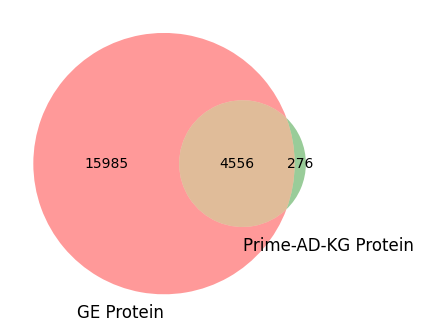

In [35]:
from matplotlib_venn import *
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
venn2(subsets=(ge_proteins,kg_proteins),
      set_labels=('GE Protein','Prime-AD-KG Protein'),)
plt.show()

In [15]:
import numpy as np

ref_mean = ge_df.loc[ge_df.index].mean(axis=0)

ref_mean
    

gene
A1BG       3.307121
A1CF       2.374262
A2M        3.419566
A2ML1      2.217245
A3GALT2    2.725172
             ...   
ZYG11A     2.006906
ZYG11B     5.457575
ZYX        9.323942
ZZEF1      7.065644
ZZZ3       5.093993
Length: 20541, dtype: float64

In [16]:
output_df = pd.DataFrame(0, index=ge_df.index, columns=ge_df.columns)
output_df[ge_df >= ref_mean] = 1
output_df[ge_df < ref_mean] = -1
output_df

gene,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AACSP1,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
116_S_1249,1,-1,-1,1,1,-1,1,1,1,-1,...,1,-1,-1,1,1,-1,-1,-1,1,1
037_S_4410,-1,-1,1,-1,-1,-1,-1,-1,1,-1,...,1,1,1,1,1,-1,-1,-1,-1,1
006_S_4153,-1,-1,1,-1,-1,-1,-1,-1,-1,1,...,1,1,-1,1,-1,1,1,-1,1,1
116_S_1232,1,-1,1,-1,-1,-1,1,1,1,1,...,1,1,1,-1,-1,1,1,-1,1,-1
099_S_4205,1,1,-1,-1,-1,-1,-1,-1,-1,-1,...,1,1,1,1,1,1,1,-1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
009_S_2381,-1,1,1,1,1,1,1,-1,-1,1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,-1
053_S_4557,1,-1,1,1,1,1,1,1,1,1,...,-1,-1,1,-1,1,-1,-1,1,1,-1
073_S_4300,1,1,1,-1,-1,-1,1,1,1,1,...,-1,1,1,-1,1,1,-1,1,-1,-1
041_S_4014,1,1,1,1,1,1,1,1,-1,1,...,-1,-1,1,-1,-1,1,-1,1,-1,-1


In [13]:
design = pd.read_csv("../AD/data/ADNI/design_with_real_target.tsv", index_col=0, sep="\t")
design['Target'] = design['Old_Target'].map({"Control":0, "Disease":1})
design

,Old_Target,Target
FileName,,
116_S_1249,Control,0
037_S_4410,Control,0
006_S_4153,Disease,1
116_S_1232,Control,0
099_S_4205,Disease,1
...,...,...
009_S_2381,Disease,1
053_S_4557,Disease,1
073_S_4300,Disease,1
